In [30]:
# ============================================================
# 0) IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1) CONFIG
# ============================================================
PATH_EXCEL  = "raw/ivf_indice.xlsx"   # <- ajusta si está en otra carpeta
SHEET_NAME  = "IVF-indice"

# Para esta figura: índice rebased a promedio anual 2019 = 100
REBASE_YEAR = 2018

# Colores (aprox. a la figura que compartiste)
COLORS = {
    "Minería": "#1f77b4",                      # azul
    "Construcción": "#2ca02c",                 # verde
    "Electricidad, agua y gas": "#d4a72c",     # amarillo/dorado
    "Manufacturas": "#b22222",                 # rojo
}

# ============================================================
# 2) LECTOR ROBUSTO PARA ESTE EXCEL "MATRIZ"
# ============================================================
MONTH_MAP = {
    "ENE": 1, "FEB": 2, "MAR": 3, "ABR": 4, "MAY": 5, "JUN": 6,
    "JUL": 7, "AGO": 8, "SEP": 9, "OCT": 10, "NOV": 11, "DIC": 12,
}

def read_ivf_matrix(path_excel: str, sheet_name: str) -> pd.DataFrame:
    """
    Lee el formato de INEGI: una tabla con:
      - Col 1: denominación (serie)
      - Row header año (p.ej., 1993, 1994, ...)
      - Row header mes (ENE, FEB, ...)
      - Celdas: valores del índice
    Devuelve df largo: [serie, date, value]
    """
    raw = pd.read_excel(path_excel, sheet_name=sheet_name, header=None)

    # Encuentra la fila donde están los meses (contiene "ENE")
    month_row_candidates = raw.index[(raw.astype(str) == "ENE").any(axis=1)].tolist()
    if not month_row_candidates:
        raise ValueError("No encontré la fila de meses (ENE). Revisa el formato del Excel.")
    r_month = month_row_candidates[0]

    # En este archivo, la fila de años está típicamente justo arriba
    r_year  = r_month - 1

    # La fila donde empieza la data: primera fila debajo de meses con "TOTAL" en col 1 o similar
    r_data_start = r_month + 1

    # Identifica desde qué columna empiezan los meses (col donde aparece ENE)
    c_start_candidates = raw.columns[raw.iloc[r_month].astype(str).eq("ENE")]
    if len(c_start_candidates) == 0:
        raise ValueError("No pude detectar la columna de inicio (ENE).")
    c_start = int(c_start_candidates[0])

    # Arma el vector de años por columna (forward fill)
    years = raw.iloc[r_year, c_start:].copy()
    years = pd.to_numeric(years, errors="coerce").ffill()

    # Arma el vector de meses por columna
    months = raw.iloc[r_month, c_start:].astype(str).str.strip().str.upper()
    months = months.map(MONTH_MAP)

    # Construye fechas por columna
    date_index = pd.to_datetime(
        {"year": years.astype(int), "month": months.astype(int), "day": 1},
        errors="coerce"
    )

    # Toma la columna de serie (denominación) y las columnas de valores
    series_col = 1  # en tu archivo, la denominación viene en la col 1
    data = raw.iloc[r_data_start:, [series_col] + list(range(c_start, raw.shape[1]))].copy()
    data.columns = ["serie"] + list(date_index)

    # Limpia filas sin nombre de serie
    data["serie"] = data["serie"].astype(str).str.strip()
    data = data[data["serie"].notna() & (data["serie"] != "") & (data["serie"].str.lower() != "nan")]

    # Pasa a largo
    long = data.melt(id_vars="serie", var_name="date", value_name="value")
    long["date"] = pd.to_datetime(long["date"], errors="coerce")
    long["value"] = pd.to_numeric(long["value"], errors="coerce")
    long = long.dropna(subset=["date", "value"])

    return long.sort_values(["serie", "date"]).reset_index(drop=True)

df_long = read_ivf_matrix(PATH_EXCEL, SHEET_NAME)

# Vista rápida
display(df_long.head())
print("Series disponibles (ejemplo):")
print(sorted(df_long["serie"].unique())[:30])


,serie,date,value
0,Construcción,1993-01-01,68.086525
1,Construcción,1993-02-01,70.049339
2,Construcción,1993-03-01,70.195985
3,Construcción,1993-04-01,69.634600
4,Construcción,1993-05-01,70.683077


Series disponibles (ejemplo):
['Construcción', 'Construcción de obras de ingeniería civil', 'Curtido y acabado de cuero y piel, y fabricación de productos de cuero, piel y materiales sucedáneos', 'Edificación', 'Extracción de petróleo y gas', 'Fabricación de accesorios, aparatos eléctricos y equipo de generación de energía eléctrica', 'Fabricación de equipo de computación, comunicación, medición y de otros equipos, componentes y accesorios electrónicos', 'Fabricación de equipo de transporte', 'Fabricación de insumos textiles y acabado de textiles', 'Fabricación de maquinaria y equipo', 'Fabricación de muebles, colchones y persianas', 'Fabricación de prendas de vestir', 'Fabricación de productos a base de minerales no metálicos', 'Fabricación de productos derivados del petróleo y del carbón', 'Fabricación de productos metálicos', 'Fabricación de productos textiles, excepto prendas de vestir', 'Generación, transmisión, distribución y comercialización de energía eléctrica, suministro de a

In [31]:
# ============================================================
# 3) SELECCIONAR SERIES (ROBUSTO: por keywords)
# ============================================================
def norm(s: str) -> str:
    return (
        str(s)
        .strip()
        .lower()
        .replace("\u00a0", " ")  # non-breaking space
    )

def find_series(series_list, must_have=(), any_of=(), must_not=()):
    """
    Regresa la primera serie cuyo nombre:
      - contenga TODOS los tokens en must_have
      - contenga AL MENOS UNO en any_of (si se especifica)
      - NO contenga ninguno en must_not
    """
    for s in series_list:
        ss = norm(s)
        if any(tok in ss for tok in must_not):
            continue
        if any(tok not in ss for tok in must_have):
            continue
        if any_of and not any(tok in ss for tok in any_of):
            continue
        return s
    return None

all_series = df_long["serie"].unique().tolist()

s_mineria = find_series(all_series, must_have=("miner",))
s_constr  = find_series(all_series, must_have=("constr",))
# Manufacturas suele venir como "industrias manufactureras" o similar
s_manuf   = find_series(all_series, must_have=("manuf",), must_not=("no", "sin")) \
            or find_series(all_series, must_have=("industri",), any_of=("manufact", "manuf"))
# Electricidad/agua/gas viene larguísima
s_elec    = find_series(all_series, must_have=("electric",), any_of=("agua", "gas")) \
            or find_series(all_series, must_have=("generación",), any_of=("agua", "gas")) \
            or find_series(all_series, must_have=("transm",), any_of=("agua", "gas"))

missing = {
    "Minería": s_mineria,
    "Construcción": s_constr,
    "Manufacturas": s_manuf,
    "Electricidad, agua y gas": s_elec,
}
print("Match de series detectadas:")
for k, v in missing.items():
    print(f"- {k}: {v}")

if any(v is None for v in missing.values()):
    raise ValueError(
        "No pude identificar todas las series automáticamente. "
        "Imprime `sorted(df_long['serie'].unique())` y buscamos el nombre exacto."
    )

series_map = {
    "Minería": s_mineria,
    "Construcción": s_constr,
    "Manufacturas": s_manuf,
    "Electricidad, agua y gas": s_elec,
}

sel = df_long[df_long["serie"].isin(series_map.values())].copy()
sel["serie_plot"] = sel["serie"].map({v: k for k, v in series_map.items()})
sel = sel[sel["date"] >= "2018-01-01"].copy()


Match de series detectadas:
- Minería: Fabricación de productos a base de minerales no metálicos
- Construcción: Construcción
- Manufacturas: Industrias manufactureras
- Electricidad, agua y gas: Generación, transmisión, distribución y comercialización de energía eléctrica, suministro de agua y de gas natural por ductos al consumidor final


In [32]:
# ============================================================
# 4) REBASE A PROMEDIO ANUAL 2019 = 100 (a.e.)
# ============================================================
sel["year"] = sel["date"].dt.year
base = (sel[sel["year"] == REBASE_YEAR]
        .groupby("serie_plot")["value"]
        .mean()
        .rename("base2019"))

sel = sel.merge(base, on="serie_plot", how="left")
sel["value_rebased"] = sel["value"] / sel["base2019"] * 100

# Formato wide para graficar más fácil
wide = sel.pivot_table(index="date", columns="serie_plot", values="value_rebased").sort_index()
display(wide.tail())


serie_plot,Construcción,"Electricidad, agua y gas",Manufacturas,Minería
date,,,,
2025-07-01,102.898698,66.318750,105.335456,97.913567
2025-08-01,100.910477,67.062849,105.412092,98.079076
2025-09-01,98.783264,67.367324,105.653338,97.418470
2025-10-01,102.845590,68.439362,105.424198,97.111057
2025-11-01,104.461726,68.460776,105.934842,97.712154


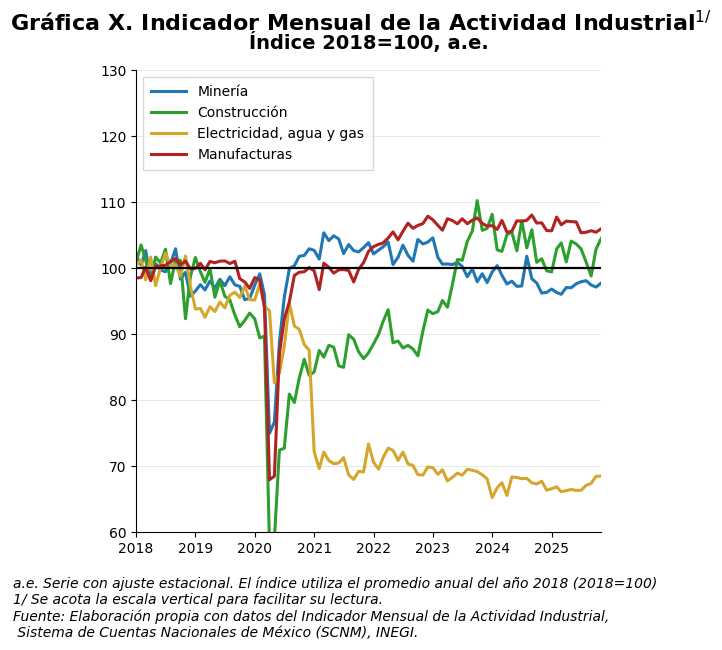

In [33]:
# ============================================================
# 5) GRAFICAR CON FORMATO "BANXICO/INEGI-LIKE"
# ============================================================
plt.close("all")
fig, ax = plt.subplots(1, 1, figsize=(6, 6))  # [left, bottom, width, height]

order = ["Minería", "Construcción", "Electricidad, agua y gas", "Manufacturas"]

for name in order:
    ax.plot(
        wide.index, wide[name],
        lw=2.2,
        color=COLORS[name],
        label=name
    )

# Línea base 100
ax.axhline(100, color="black", lw=1.6)

# Ejes y ticks
ax.set_xlim(wide.index.min(), wide.index.max())
ax.set_ylim(60, 130)  # similar a la figura; ajusta si lo necesitas
ax.set_yticks(np.arange(60, 131, 10))
ax.tick_params(axis="both", labelsize=10)

# Grid suave (vertical casi imperceptible, horizontal útil)
ax.yaxis.grid(True, linewidth=0.6, alpha=0.35)
ax.xaxis.grid(False)

# Leyenda dentro, arriba-izquierda (como tu ejemplo)
 # --- Leyenda tipo tu ejemplo (recuadro, sin encimar)
ax.legend(
    loc="upper left",
    frameon=True,
    fancybox=False,
    framealpha=.75,
    borderpad=0.6,
    handlelength=2.5,
    handletextpad=0.8,
    columnspacing=1.2)

# Títulos
fig.suptitle("Gráfica X. Indicador Mensual de la Actividad Industrial$^{1/}$",
         fontsize=16, fontweight="bold", y=0.98)
ax.set_title(f"Índice {REBASE_YEAR}=100, a.e.",
         fontsize=14, fontweight="bold", pad=15)

# Nota al pie (centrada/menos a la izquierda)
nota = (
    "a.e. Serie con ajuste estacional. El índice utiliza el promedio anual del año "
    f"{REBASE_YEAR} ({REBASE_YEAR}=100)\n"
    "1/ Se acota la escala vertical para facilitar su lectura.\n"
    "Fuente: Elaboración propia con datos del Indicador Mensual de la Actividad Industrial, \n "
    "Sistema de Cuentas Nacionales de México (SCNM), INEGI."
)
fig.text(-0.08, -0.07, nota, fontsize=10, style="italic", ha="left", va="bottom")

# Limpieza de spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()


In [34]:
# ============================================================
# 0) Utilidades rápidas para buscar candidatos
# ============================================================
def norm(s: str) -> str:
    return (
        str(s).strip().lower()
        .replace("\u00a0", " ")
        .replace("á","a").replace("é","e").replace("í","i").replace("ó","o").replace("ú","u")
    )

def contains_all(name, toks):
    ss = norm(name)
    return all(t in ss for t in toks)

def candidates(series_list, must=(), any_of=(), top=40):
    out = []
    for s in series_list:
        ss = norm(s)
        if must and not all(t in ss for t in must):
            continue
        if any_of and not any(t in ss for t in any_of):
            continue
        out.append(s)
    return out[:top]

all_series = sorted(df_long["serie"].unique())

# ============================================================
# 1) Buscar "Manufacturas" total (sin especificar subrama)
# ============================================================
# Priorizamos algo que contenga "manufact" pero NO contenga "equipo" ni "transporte"
manuf_total_candidates = [
    s for s in all_series
    if ("manufact" in norm(s)) and ("equipo" not in norm(s)) and ("transporte" not in norm(s))
]

print("=== Candidatos para Manufacturas (TOTAL) ===")
print("\n".join(manuf_total_candidates[:30]) if manuf_total_candidates else "[No encontré candidatos obvios]")

# Si hay uno, tomamos el primero (si hay varios, tú eliges el correcto visualmente)
s_manuf_total = manuf_total_candidates[0] if manuf_total_candidates else None
print("\nElegido como Manufacturas total:", s_manuf_total)

# ============================================================
# 2) Candidatos de vehículos (por si vienen con otro nombre)
# ============================================================
veh_cands = candidates(all_series, any_of=("veh", "autom", "camion", "liger", "pesad", "unidad"))
print("\n=== Candidatos relacionados con vehículos (si existen) ===")
print("\n".join(veh_cands) if veh_cands else "[No aparece nada de vehículos en esta hoja]")

# ============================================================
# 3) Construir "Manufacturas sin equipo de transporte" si hay total
# ============================================================
s_equipo_trans = "Fabricación de equipo de transporte"  # lo que ya detectaste

if s_manuf_total is None:
    print("\n[Info] No puedo construir 'Manufacturas sin equipo de transporte' porque no encontré Manufacturas total.")
else:
    # Hacemos merge por fecha
    m_total = df_long[df_long["serie"].eq(s_manuf_total)][["date","value"]].rename(columns={"value":"manuf_total"})
    m_trans = df_long[df_long["serie"].eq(s_equipo_trans)][["date","value"]].rename(columns={"value":"eq_trans"})
    m = m_total.merge(m_trans, on="date", how="inner").sort_values("date")

    # diferencia (ojo: esto asume que "contribución"/"índice" es aditivo en nivel; si tu serie es índice,
    # esta resta es válida solo si son índices compatibles del mismo universo. En INEGI suele ser consistente.)
    m["manuf_sin_trans"] = m["manuf_total"] - m["eq_trans"]

    display(m.head())
    print("\nListo: construí una serie derivada 'manuf_sin_trans' (Manufacturas sin equipo de transporte).")


=== Candidatos para Manufacturas (TOTAL) ===
Industrias manufactureras
Otras industrias manufactureras

Elegido como Manufacturas total: Industrias manufactureras

=== Candidatos relacionados con vehículos (si existen) ===
[No aparece nada de vehículos en esta hoja]


,date,manuf_total,eq_trans,manuf_sin_trans
0,1993-01-01,56.770736,24.501103,32.269633
1,1993-02-01,59.073122,26.812993,32.260129
2,1993-03-01,59.777948,27.642612,32.135337
3,1993-04-01,59.204189,25.813427,33.390762
4,1993-05-01,58.828165,25.751584,33.076581



Listo: construí una serie derivada 'manuf_sin_trans' (Manufacturas sin equipo de transporte).


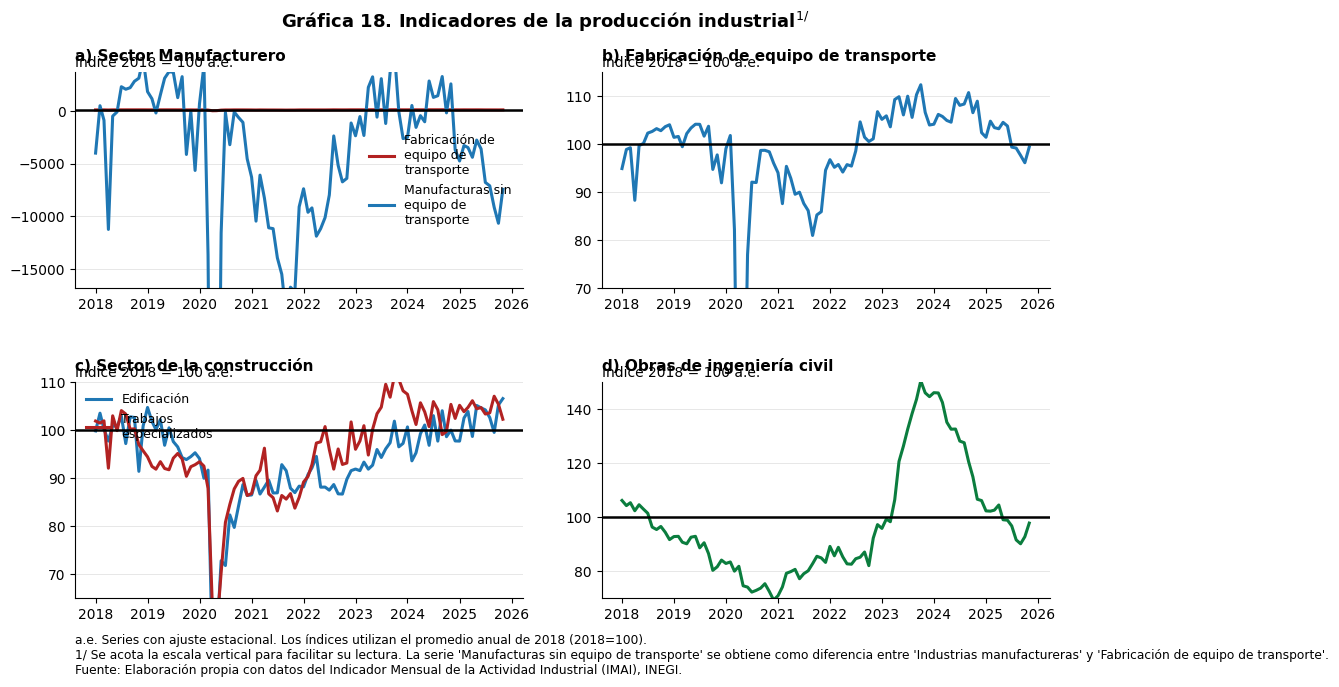

In [35]:
# ============================================================
# Gráfica tipo "Banxico" (4 paneles) con IMAI-INEGI
# Base: 2018 = 100 (a.e.), series desestacionalizadas
#
# - Lee tu Excel (ivf_indice.xlsx / hoja "IVF-indice") en formato matriz
# - Convierte a formato largo (serie, date, value)
# - Construye:
#   (a) Sector manufacturero: Equipo de transporte vs Manufacturas sin equipo (derivado)
#   (b) Fabricación de equipo de transporte (índice, NO unidades)
#   (c) Construcción: Edificación vs Trabajos especializados
#   (d) Obras de ingeniería civil
# - Mantiene línea base 100, colores, layout 2x2 y nota al pie
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1) CONFIG
# ============================================================
PATH_EXCEL = "raw/ivf_indice.xlsx"
SHEET_NAME = "IVF-indice"

START_DATE = "2018-01-01"   # rango visual como tu ejemplo
BASE_YEAR  = 2018           # <- lo que pediste (base 2018 = 100)
# Nota: tu archivo ya dice "Índice Base 2018 = 100". Aun así rebaseamos a prom. anual 2018
# para asegurarnos de que el nivel 100 sea consistente con "a.e." (promedio anual).

# Colores (estilo Banxico aproximado)
BLUE  = "#1f77b4"
RED   = "#b22222"
GREEN = "#0b7d3e"
BLACK = "#000000"

# ============================================================
# 2) LECTOR ROBUSTO (Excel tipo "matriz" con años/meses)
# ============================================================
MONTH_MAP = {
    "ENE": 1, "FEB": 2, "MAR": 3, "ABR": 4, "MAY": 5, "JUN": 6,
    "JUL": 7, "AGO": 8, "SEP": 9, "OCT": 10, "NOV": 11, "DIC": 12,
}

def read_ivf_matrix(path_excel: str, sheet_name: str) -> pd.DataFrame:
    raw = pd.read_excel(path_excel, sheet_name=sheet_name, header=None)

    # fila donde están los meses (contiene "ENE")
    month_row_candidates = raw.index[(raw.astype(str) == "ENE").any(axis=1)].tolist()
    if not month_row_candidates:
        raise ValueError("No encontré la fila de meses (ENE). Revisa el formato del Excel.")
    r_month = month_row_candidates[0]
    r_year  = r_month - 1
    r_data_start = r_month + 1

    # columna donde empieza ENE
    c_start_candidates = raw.columns[raw.iloc[r_month].astype(str).eq("ENE")]
    if len(c_start_candidates) == 0:
        raise ValueError("No pude detectar la columna de inicio (ENE).")
    c_start = int(c_start_candidates[0])

    # años por columna (ffill)
    years = raw.iloc[r_year, c_start:].copy()
    years = pd.to_numeric(years, errors="coerce").ffill()

    # meses por columna
    months = raw.iloc[r_month, c_start:].astype(str).str.strip().str.upper()
    months = months.map(MONTH_MAP)

    # fechas por columna
    date_index = pd.to_datetime(
        {"year": years.astype(int), "month": months.astype(int), "day": 1},
        errors="coerce"
    )

    # columna de denominación (en este archivo suele ser col 1)
    series_col = 1
    data = raw.iloc[r_data_start:, [series_col] + list(range(c_start, raw.shape[1]))].copy()
    data.columns = ["serie"] + list(date_index)

    # limpia filas sin nombre de serie
    data["serie"] = data["serie"].astype(str).str.strip()
    data = data[data["serie"].notna() & (data["serie"] != "") & (data["serie"].str.lower() != "nan")]

    long = data.melt(id_vars="serie", var_name="date", value_name="value")
    long["date"]  = pd.to_datetime(long["date"], errors="coerce")
    long["value"] = pd.to_numeric(long["value"], errors="coerce")
    long = long.dropna(subset=["date", "value"])

    return long.sort_values(["serie", "date"]).reset_index(drop=True)

df_long = read_ivf_matrix(PATH_EXCEL, SHEET_NAME)

# ============================================================
# 3) SELECCIÓN DE SERIES (en tu archivo ya identificadas)
# ============================================================
S_MANUF_TOTAL = "Industrias manufactureras"
S_EQ_TRANS    = "Fabricación de equipo de transporte"
S_EDIF        = "Edificación"
S_TRAB_ESP    = "Trabajos especializados para la construcción"
S_ING_CIVIL   = "Construcción de obras de ingeniería civil"

need = [S_MANUF_TOTAL, S_EQ_TRANS, S_EDIF, S_TRAB_ESP, S_ING_CIVIL]
missing = [s for s in need if s not in set(df_long["serie"].unique())]
if missing:
    raise ValueError("No encuentro estas series en df_long:\n- " + "\n- ".join(missing))

# ============================================================
# 4) ARMAR DATASETS + SERIE DERIVADA "Manufacturas sin equipo"
# ============================================================
def get_series(name):
    d = df_long[df_long["serie"].eq(name)].copy()
    d = d.sort_values("date")
    d = d[d["date"] >= pd.to_datetime(START_DATE)]
    return d

m_total = get_series(S_MANUF_TOTAL)[["date","value"]].rename(columns={"value":"manuf_total"})
m_trans = get_series(S_EQ_TRANS)[["date","value"]].rename(columns={"value":"eq_trans"})

mA = m_total.merge(m_trans, on="date", how="inner").sort_values("date")
mA["manuf_sin_trans"] = mA["manuf_total"] - mA["eq_trans"]

B = get_series(S_EQ_TRANS)[["date","value"]].rename(columns={"value":"eq_trans"})

C_ed = get_series(S_EDIF)[["date","value"]].rename(columns={"value":"edif"})
C_te = get_series(S_TRAB_ESP)[["date","value"]].rename(columns={"value":"trab_esp"})
mC = C_ed.merge(C_te, on="date", how="inner").sort_values("date")

D = get_series(S_ING_CIVIL)[["date","value"]].rename(columns={"value":"ing_civil"})

# ============================================================
# 5) REBASE a promedio anual BASE_YEAR = 100 (a.e.)
# ============================================================
def rebase_to_year_avg(d: pd.DataFrame, col: str, base_year: int) -> pd.DataFrame:
    out = d.copy()
    out["year"] = out["date"].dt.year
    base = out.loc[out["year"].eq(base_year), col].mean()
    if pd.isna(base) or base == 0:
        raise ValueError(f"No pude calcular el promedio anual {base_year} para {col}.")
    out[col+"_rebased"] = out[col] / base * 100
    return out.drop(columns=["year"])

mA = rebase_to_year_avg(mA, "eq_trans", BASE_YEAR)
mA = rebase_to_year_avg(mA, "manuf_sin_trans", BASE_YEAR)

B  = rebase_to_year_avg(B, "eq_trans", BASE_YEAR)

mC = rebase_to_year_avg(mC, "edif", BASE_YEAR)
mC = rebase_to_year_avg(mC, "trab_esp", BASE_YEAR)

D  = rebase_to_year_avg(D, "ing_civil", BASE_YEAR)

# ============================================================
# 6) GRÁFICA 2x2 (mismo tamaño paneles) + nota al pie
# ============================================================
plt.close("all")
fig = plt.figure(figsize=(11.2, 7.2))

# axes manuales para igualar dimensiones
ax_a = fig.add_axes([0.08, 0.58, 0.40, 0.30])
ax_b = fig.add_axes([0.55, 0.58, 0.40, 0.30])
ax_c = fig.add_axes([0.08, 0.15, 0.40, 0.30])
ax_d = fig.add_axes([0.55, 0.15, 0.40, 0.30])

# Título
fig.text(0.5, 0.95, "Gráfica 18. Indicadores de la producción industrial$^{1/}$",
         ha="center", va="center", fontsize=13, fontweight="bold")

# Estilo común
def style_ax(ax):
    ax.axhline(100, color=BLACK, lw=1.8)
    ax.yaxis.grid(True, linewidth=0.6, alpha=0.35)
    ax.xaxis.grid(False)
    ax.tick_params(labelsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# (a) Manufacturero
ax_a.plot(mA["date"], mA["eq_trans_rebased"], color=RED,  lw=2.2,
          label="Fabricación de\nequipo de\ntransporte")
ax_a.plot(mA["date"], mA["manuf_sin_trans_rebased"], color=BLUE, lw=2.2,
          label="Manufacturas sin\nequipo de\ntransporte")
style_ax(ax_a)
ax_a.set_title("a) Sector Manufacturero", loc="left", fontsize=11, fontweight="bold", pad=8)
ax_a.text(0.0, 1.01, f"Índice {BASE_YEAR} = 100 a.e.", transform=ax_a.transAxes, fontsize=10, va="bottom")
ax_a.legend(loc="center right", frameon=False, fontsize=9)

ya = pd.concat([mA["eq_trans_rebased"], mA["manuf_sin_trans_rebased"]])
ax_a.set_ylim(np.floor(ya.quantile(0.02)/5)*5, np.ceil(ya.quantile(0.98)/5)*5)

# (b) Equipo de transporte (índice)
ax_b.plot(B["date"], B["eq_trans_rebased"], color=BLUE, lw=2.2)
style_ax(ax_b)
ax_b.set_title("b) Fabricación de equipo de transporte", loc="left", fontsize=11, fontweight="bold", pad=8)
ax_b.text(0.0, 1.01, f"Índice {BASE_YEAR} = 100 a.e.", transform=ax_b.transAxes, fontsize=10, va="bottom")

yb = B["eq_trans_rebased"]
ax_b.set_ylim(np.floor(yb.quantile(0.02)/5)*5, np.ceil(yb.quantile(0.98)/5)*5)

# (c) Construcción
ax_c.plot(mC["date"], mC["edif_rebased"], color=BLUE, lw=2.2, label="Edificación")
ax_c.plot(mC["date"], mC["trab_esp_rebased"], color=RED,  lw=2.2, label="Trabajos\nespecializados")
style_ax(ax_c)
ax_c.set_title("c) Sector de la construcción", loc="left", fontsize=11, fontweight="bold", pad=8)
ax_c.text(0.0, 1.01, f"Índice {BASE_YEAR} = 100 a.e.", transform=ax_c.transAxes, fontsize=10, va="bottom")
ax_c.legend(loc="upper left", frameon=False, fontsize=9)

yc = pd.concat([mC["edif_rebased"], mC["trab_esp_rebased"]])
ax_c.set_ylim(np.floor(yc.quantile(0.02)/5)*5, np.ceil(yc.quantile(0.98)/5)*5)

# (d) Ingeniería civil
ax_d.plot(D["date"], D["ing_civil_rebased"], color=GREEN, lw=2.2)
style_ax(ax_d)
ax_d.set_title("d) Obras de ingeniería civil", loc="left", fontsize=11, fontweight="bold", pad=8)
ax_d.text(0.0, 1.01, f"Índice {BASE_YEAR} = 100 a.e.", transform=ax_d.transAxes, fontsize=10, va="bottom")

yd = D["ing_civil_rebased"]
# ingeniería civil suele moverse más; dejamos ticks más amplios
ax_d.set_ylim(np.floor(yd.quantile(0.02)/10)*10, np.ceil(yd.quantile(0.98)/10)*10)

# Nota al pie
nota = (
    f"a.e. Series con ajuste estacional. Los índices utilizan el promedio anual de {BASE_YEAR} ({BASE_YEAR}=100).\n"
    "1/ Se acota la escala vertical para facilitar su lectura. "
    "La serie 'Manufacturas sin equipo de transporte' se obtiene como diferencia entre "
    "'Industrias manufactureras' y 'Fabricación de equipo de transporte'.\n"
    "Fuente: Elaboración propia con datos del Indicador Mensual de la Actividad Industrial (IMAI), INEGI."
)
fig.text(0.08, 0.04, nota, ha="left", va="bottom", fontsize=8.8)

plt.show()


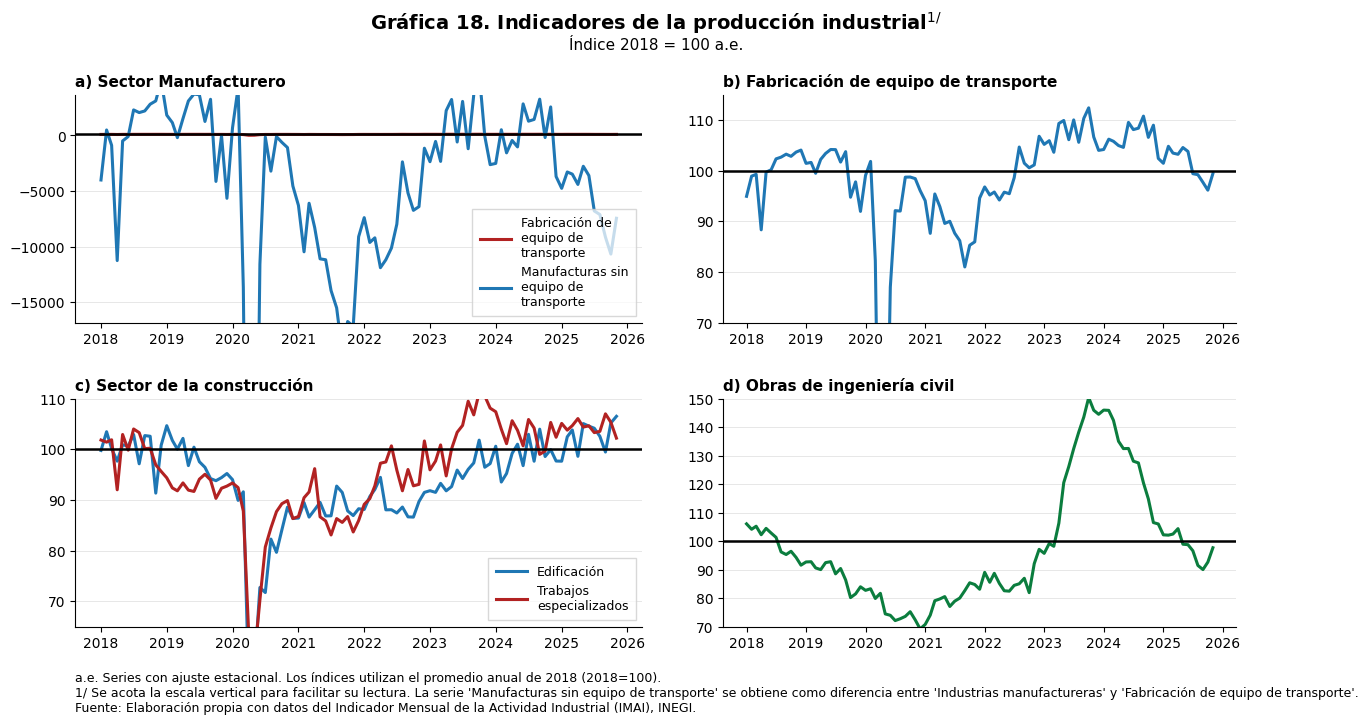

In [36]:
# ============================================================
# Gráfica 18 (4 paneles) — FIX layout (sin encimes)
# - "Índice 2018 = 100 a.e." se pone UNA sola vez bajo el título global
# - Títulos de panel con buen padding
# - Leyendas dentro pero sin estorbar (y en (a) fuera del trazo)
# - Nota al pie alineada y sin invadir paneles
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
PATH_EXCEL = "raw/ivf_indice.xlsx"
SHEET_NAME = "IVF-indice"

START_DATE = "2018-01-01"
BASE_YEAR  = 2018

BLUE  = "#1f77b4"
RED   = "#b22222"
GREEN = "#0b7d3e"
BLACK = "#000000"

# =========================
# LECTOR MATRIZ
# =========================
MONTH_MAP = {
    "ENE": 1, "FEB": 2, "MAR": 3, "ABR": 4, "MAY": 5, "JUN": 6,
    "JUL": 7, "AGO": 8, "SEP": 9, "OCT": 10, "NOV": 11, "DIC": 12,
}

def read_ivf_matrix(path_excel: str, sheet_name: str) -> pd.DataFrame:
    raw = pd.read_excel(path_excel, sheet_name=sheet_name, header=None)

    month_row_candidates = raw.index[(raw.astype(str) == "ENE").any(axis=1)].tolist()
    if not month_row_candidates:
        raise ValueError("No encontré la fila de meses (ENE).")
    r_month = month_row_candidates[0]
    r_year  = r_month - 1
    r_data_start = r_month + 1

    c_start_candidates = raw.columns[raw.iloc[r_month].astype(str).eq("ENE")]
    if len(c_start_candidates) == 0:
        raise ValueError("No pude detectar la columna ENE.")
    c_start = int(c_start_candidates[0])

    years = pd.to_numeric(raw.iloc[r_year, c_start:], errors="coerce").ffill()
    months = raw.iloc[r_month, c_start:].astype(str).str.strip().str.upper().map(MONTH_MAP)

    dates = pd.to_datetime({"year": years.astype(int), "month": months.astype(int), "day": 1}, errors="coerce")

    series_col = 1
    data = raw.iloc[r_data_start:, [series_col] + list(range(c_start, raw.shape[1]))].copy()
    data.columns = ["serie"] + list(dates)

    data["serie"] = data["serie"].astype(str).str.strip()
    data = data[data["serie"].notna() & (data["serie"] != "") & (data["serie"].str.lower() != "nan")]

    long = data.melt(id_vars="serie", var_name="date", value_name="value")
    long["date"]  = pd.to_datetime(long["date"], errors="coerce")
    long["value"] = pd.to_numeric(long["value"], errors="coerce")
    long = long.dropna(subset=["date", "value"]).sort_values(["serie", "date"]).reset_index(drop=True)
    return long

df_long = read_ivf_matrix(PATH_EXCEL, SHEET_NAME)

# =========================
# SERIES (ya confirmadas)
# =========================
S_MANUF_TOTAL = "Industrias manufactureras"
S_EQ_TRANS    = "Fabricación de equipo de transporte"
S_EDIF        = "Edificación"
S_TRAB_ESP    = "Trabajos especializados para la construcción"
S_ING_CIVIL   = "Construcción de obras de ingeniería civil"

need = [S_MANUF_TOTAL, S_EQ_TRANS, S_EDIF, S_TRAB_ESP, S_ING_CIVIL]
missing = [s for s in need if s not in set(df_long["serie"].unique())]
if missing:
    raise ValueError("Faltan series en el Excel:\n- " + "\n- ".join(missing))

def get_series(name):
    d = df_long[df_long["serie"].eq(name)].copy().sort_values("date")
    d = d[d["date"] >= pd.to_datetime(START_DATE)]
    return d[["date","value"]]

# =========================
# DERIVADAS + REBASE (promedio anual BASE_YEAR = 100)
# =========================
def rebase_year_avg(d: pd.DataFrame, col: str, base_year: int) -> pd.DataFrame:
    out = d.copy()
    out["year"] = out["date"].dt.year
    base = out.loc[out["year"].eq(base_year), col].mean()
    if pd.isna(base) or base == 0:
        raise ValueError(f"No pude calcular promedio anual {base_year} para {col}.")
    out[col+"_rb"] = out[col] / base * 100
    return out.drop(columns=["year"])

# (a) Manufacturero: eq_trans vs manuf_sin_trans (diferencia)
m_total = get_series(S_MANUF_TOTAL).rename(columns={"value":"manuf_total"})
m_trans = get_series(S_EQ_TRANS).rename(columns={"value":"eq_trans"})
A = m_total.merge(m_trans, on="date", how="inner")
A["manuf_sin_trans"] = A["manuf_total"] - A["eq_trans"]

A = rebase_year_avg(A, "eq_trans", BASE_YEAR)
A = rebase_year_avg(A, "manuf_sin_trans", BASE_YEAR)

# (b) eq_trans solo
B = get_series(S_EQ_TRANS).rename(columns={"value":"eq_trans"})
B = rebase_year_avg(B, "eq_trans", BASE_YEAR)

# (c) construcción: edificación vs trabajos esp
C_ed = get_series(S_EDIF).rename(columns={"value":"edif"})
C_te = get_series(S_TRAB_ESP).rename(columns={"value":"trab_esp"})
C = C_ed.merge(C_te, on="date", how="inner")

C = rebase_year_avg(C, "edif", BASE_YEAR)
C = rebase_year_avg(C, "trab_esp", BASE_YEAR)

# (d) ingeniería civil
D = get_series(S_ING_CIVIL).rename(columns={"value":"ing_civil"})
D = rebase_year_avg(D, "ing_civil", BASE_YEAR)

# =========================
# PLOT 2x2 (SIN ENCIMES)
# =========================
plt.close("all")
fig = plt.figure(figsize=(13.5, 7.6))
 # --- Leyenda tipo tu ejemplo (recuadro, sin encimar)


# Layout: más margen arriba para título/subtítulo, y abajo para nota
ax_a = fig.add_axes([0.07, 0.57, 0.42, 0.30])
ax_b = fig.add_axes([0.55, 0.57, 0.38, 0.30])
ax_c = fig.add_axes([0.07, 0.17, 0.42, 0.30])
ax_d = fig.add_axes([0.55, 0.17, 0.38, 0.30])

# Título global + subtítulo global (UNA sola vez)
fig.text(0.5, 0.965, "Gráfica 18. Indicadores de la producción industrial$^{1/}$",
         ha="center", va="center", fontsize=14, fontweight="bold")
fig.text(0.5, 0.935, f"Índice {BASE_YEAR} = 100 a.e.",
         ha="center", va="center", fontsize=11)

def style_ax(ax):
    ax.axhline(100, color=BLACK, lw=1.8)
    ax.yaxis.grid(True, linewidth=0.6, alpha=0.35)
    ax.xaxis.grid(False)
    ax.tick_params(labelsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def set_ylim_quant(ax, series_list, step=5, qlo=0.02, qhi=0.98):
    y = pd.concat(series_list).dropna()
    lo = y.quantile(qlo)
    hi = y.quantile(qhi)
    lo = np.floor(lo/step)*step
    hi = np.ceil(hi/step)*step
    if lo == hi:
        lo -= step
        hi += step
    ax.set_ylim(lo, hi)

# (a)
ax_a.plot(A["date"], A["eq_trans_rb"], color=RED,  lw=2.2,
          label="Fabricación de\nequipo de\ntransporte")
ax_a.plot(A["date"], A["manuf_sin_trans_rb"], color=BLUE, lw=2.2,
          label="Manufacturas sin\nequipo de\ntransporte")
style_ax(ax_a)
ax_a.set_title("a) Sector Manufacturero", loc="left", fontsize=11, fontweight="bold", pad=6)

# Leyenda dentro pero a la derecha y arriba (evita tapar el centro)
leg = ax_a.legend(
    loc="lower right",
    frameon=True,
    fancybox=False,
    framealpha=.75,
    borderpad=0.6,
    handlelength=2.5,
    handletextpad=0.8,
    columnspacing=1.2,
    fontsize=9
)

set_ylim_quant(ax_a, [A["eq_trans_rb"], A["manuf_sin_trans_rb"]], step=5)

# (b)
ax_b.plot(B["date"], B["eq_trans_rb"], color=BLUE, lw=2.2)
style_ax(ax_b)
ax_b.set_title("b) Fabricación de equipo de transporte", loc="left", fontsize=11, fontweight="bold", pad=6)
set_ylim_quant(ax_b, [B["eq_trans_rb"]], step=5)

# (c)
ax_c.plot(C["date"], C["edif_rb"], color=BLUE, lw=2.2, label="Edificación")
ax_c.plot(C["date"], C["trab_esp_rb"], color=RED,  lw=2.2, label="Trabajos\nespecializados")
style_ax(ax_c)
ax_c.set_title("c) Sector de la construcción", loc="left", fontsize=11, fontweight="bold", pad=6)
leg = ax_c.legend(
    loc="lower right",
    frameon=True,
    fancybox=False,
    framealpha=.75,
    borderpad=0.6,
    handlelength=2.5,
    handletextpad=0.8,
    columnspacing=1.2,
    fontsize=9
)

set_ylim_quant(ax_c, [C["edif_rb"], C["trab_esp_rb"]], step=5)

# (d)
ax_d.plot(D["date"], D["ing_civil_rb"], color=GREEN, lw=2.2)
style_ax(ax_d)
ax_d.set_title("d) Obras de ingeniería civil", loc="left", fontsize=11, fontweight="bold", pad=6)
set_ylim_quant(ax_d, [D["ing_civil_rb"]], step=10)

# Nota al pie (bien abajo, sin invadir paneles)
nota = (
    f"a.e. Series con ajuste estacional. Los índices utilizan el promedio anual de {BASE_YEAR} ({BASE_YEAR}=100).\n"
    "1/ Se acota la escala vertical para facilitar su lectura. "
    "La serie 'Manufacturas sin equipo de transporte' se obtiene como diferencia entre "
    "'Industrias manufactureras' y 'Fabricación de equipo de transporte'.\n"
    "Fuente: Elaboración propia con datos del Indicador Mensual de la Actividad Industrial (IMAI), INEGI."
)
fig.text(0.07, 0.055, nota, ha="left", va="bottom", fontsize=9)

plt.show()


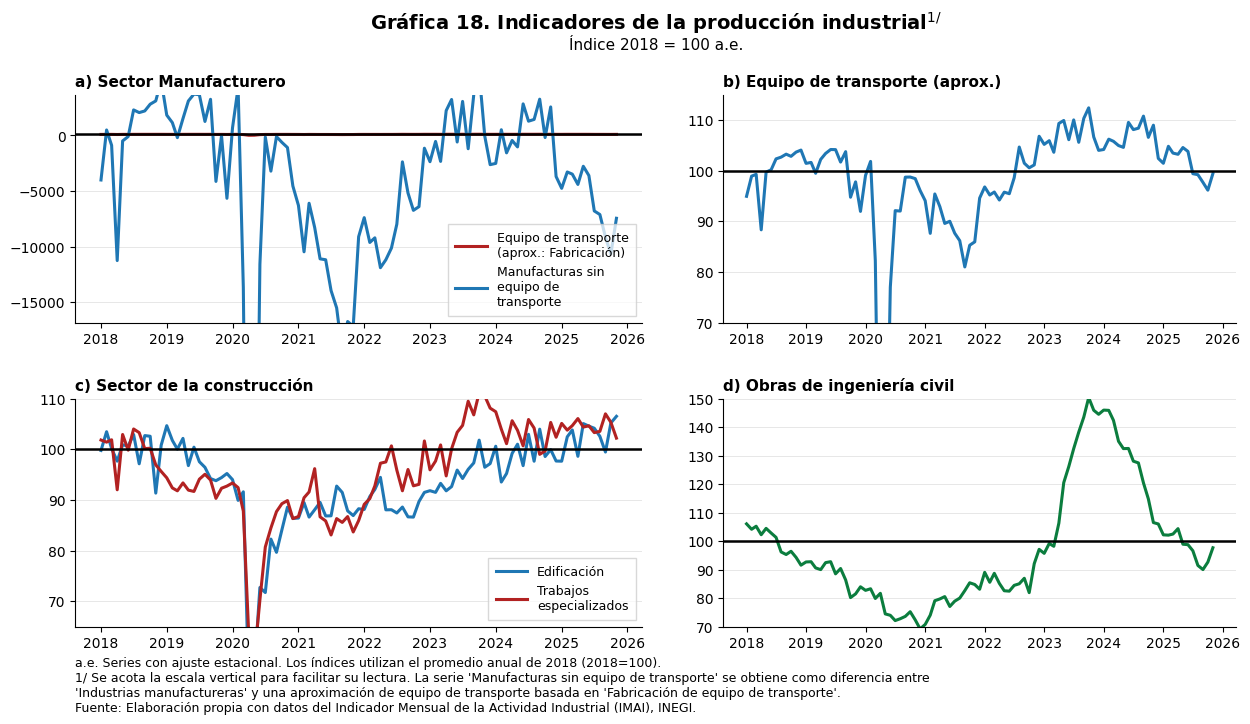

In [37]:
# ============================================================
# Gráfica 18 (4 paneles) — Versión final con APROXIMACIÓN
# Base: 2018 = 100 (a.e.), series desestacionalizadas
#
# IMPORTANTE (como pediste):
# - Usamos "Fabricación de equipo de transporte" COMO APROXIMACIÓN de
#   "Manufacturas de equipo de transporte".
# - Las leyendas y la nota lo dicen explícitamente.
# - El subtítulo "Índice 2018 = 100 a.e." va UNA sola vez bajo el título global.
# - Leyendas: recuadro semi-transparente como tu snippet.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
PATH_EXCEL = "raw/ivf_indice.xlsx"
SHEET_NAME = "IVF-indice"
START_DATE = "2018-01-01"
BASE_YEAR  = 2018

BLUE  = "#1f77b4"
RED   = "#b22222"
GREEN = "#0b7d3e"
BLACK = "#000000"

# =========================
# LECTOR MATRIZ (INEGI)
# =========================
MONTH_MAP = {
    "ENE": 1, "FEB": 2, "MAR": 3, "ABR": 4, "MAY": 5, "JUN": 6,
    "JUL": 7, "AGO": 8, "SEP": 9, "OCT": 10, "NOV": 11, "DIC": 12,
}

def read_ivf_matrix(path_excel: str, sheet_name: str) -> pd.DataFrame:
    raw = pd.read_excel(path_excel, sheet_name=sheet_name, header=None)

    month_row_candidates = raw.index[(raw.astype(str) == "ENE").any(axis=1)].tolist()
    if not month_row_candidates:
        raise ValueError("No encontré la fila de meses (ENE).")
    r_month = month_row_candidates[0]
    r_year  = r_month - 1
    r_data_start = r_month + 1

    c_start_candidates = raw.columns[raw.iloc[r_month].astype(str).eq("ENE")]
    if len(c_start_candidates) == 0:
        raise ValueError("No pude detectar la columna ENE.")
    c_start = int(c_start_candidates[0])

    years = pd.to_numeric(raw.iloc[r_year, c_start:], errors="coerce").ffill()
    months = raw.iloc[r_month, c_start:].astype(str).str.strip().str.upper().map(MONTH_MAP)
    dates = pd.to_datetime({"year": years.astype(int), "month": months.astype(int), "day": 1}, errors="coerce")

    series_col = 1
    data = raw.iloc[r_data_start:, [series_col] + list(range(c_start, raw.shape[1]))].copy()
    data.columns = ["serie"] + list(dates)

    data["serie"] = data["serie"].astype(str).str.strip()
    data = data[data["serie"].notna() & (data["serie"] != "") & (data["serie"].str.lower() != "nan")]

    long = data.melt(id_vars="serie", var_name="date", value_name="value")
    long["date"]  = pd.to_datetime(long["date"], errors="coerce")
    long["value"] = pd.to_numeric(long["value"], errors="coerce")
    long = long.dropna(subset=["date", "value"]).sort_values(["serie", "date"]).reset_index(drop=True)
    return long

df_long = read_ivf_matrix(PATH_EXCEL, SHEET_NAME)

# =========================
# SERIES (en tu archivo)
# =========================
S_MANUF_TOTAL = "Industrias manufactureras"
S_EQ_TRANS    = "Fabricación de equipo de transporte"  # <- APROX

S_EDIF        = "Edificación"
S_TRAB_ESP    = "Trabajos especializados para la construcción"
S_ING_CIVIL   = "Construcción de obras de ingeniería civil"

need = [S_MANUF_TOTAL, S_EQ_TRANS, S_EDIF, S_TRAB_ESP, S_ING_CIVIL]
missing = [s for s in need if s not in set(df_long["serie"].unique())]
if missing:
    raise ValueError("Faltan series en el Excel:\n- " + "\n- ".join(missing))

def get_series(name):
    d = df_long[df_long["serie"].eq(name)].copy().sort_values("date")
    d = d[d["date"] >= pd.to_datetime(START_DATE)]
    return d[["date", "value"]]

# =========================
# DERIVADAS + REBASE (prom anual BASE_YEAR = 100)
# =========================
def rebase_year_avg(d: pd.DataFrame, col: str, base_year: int) -> pd.DataFrame:
    out = d.copy()
    out["year"] = out["date"].dt.year
    base = out.loc[out["year"].eq(base_year), col].mean()
    if pd.isna(base) or base == 0:
        raise ValueError(f"No pude calcular promedio anual {base_year} para {col}.")
    out[col + "_rb"] = out[col] / base * 100
    return out.drop(columns=["year"])

# Panel (a): manufacturas sin eq transp = total - (aprox: fabricación equipo transp)
m_total = get_series(S_MANUF_TOTAL).rename(columns={"value": "manuf_total"})
m_trans = get_series(S_EQ_TRANS).rename(columns={"value": "eq_trans_approx"})
A = m_total.merge(m_trans, on="date", how="inner").sort_values("date")
A["manuf_sin_trans"] = A["manuf_total"] - A["eq_trans_approx"]

A = rebase_year_avg(A, "eq_trans_approx", BASE_YEAR)
A = rebase_year_avg(A, "manuf_sin_trans", BASE_YEAR)

# Panel (b): (aprox) equipo de transporte
B = get_series(S_EQ_TRANS).rename(columns={"value": "eq_trans_approx"})
B = rebase_year_avg(B, "eq_trans_approx", BASE_YEAR)

# Panel (c): construcción
C_ed = get_series(S_EDIF).rename(columns={"value": "edif"})
C_te = get_series(S_TRAB_ESP).rename(columns={"value": "trab_esp"})
C = C_ed.merge(C_te, on="date", how="inner").sort_values("date")
C = rebase_year_avg(C, "edif", BASE_YEAR)
C = rebase_year_avg(C, "trab_esp", BASE_YEAR)

# Panel (d): ingeniería civil
D = get_series(S_ING_CIVIL).rename(columns={"value": "ing_civil"})
D = rebase_year_avg(D, "ing_civil", BASE_YEAR)

# =========================
# PLOT (layout sin encimes)
# =========================
plt.close("all")
fig = plt.figure(figsize=(13.5, 7.6))

ax_a = fig.add_axes([0.07, 0.57, 0.42, 0.30])
ax_b = fig.add_axes([0.55, 0.57, 0.38, 0.30])
ax_c = fig.add_axes([0.07, 0.17, 0.42, 0.30])
ax_d = fig.add_axes([0.55, 0.17, 0.38, 0.30])

# Título global + subtítulo global (UNA sola vez)
fig.text(0.5, 0.965, "Gráfica 18. Indicadores de la producción industrial$^{1/}$",
         ha="center", va="center", fontsize=14, fontweight="bold")
fig.text(0.5, 0.935, f"Índice {BASE_YEAR} = 100 a.e.",
         ha="center", va="center", fontsize=11)

def style_ax(ax):
    ax.axhline(100, color=BLACK, lw=1.8)
    ax.yaxis.grid(True, linewidth=0.6, alpha=0.35)
    ax.xaxis.grid(False)
    ax.tick_params(labelsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def set_ylim_quant(ax, series_list, step=5, qlo=0.02, qhi=0.98):
    y = pd.concat(series_list).dropna()
    lo = y.quantile(qlo)
    hi = y.quantile(qhi)
    lo = np.floor(lo/step)*step
    hi = np.ceil(hi/step)*step
    if lo == hi:
        lo -= step
        hi += step
    ax.set_ylim(lo, hi)

# --- Leyenda tipo tu ejemplo (recuadro, sin encimar)
def boxed_legend(ax, loc="lower right"):
    leg = ax.legend(
        loc=loc,
        frameon=True,
        fancybox=False,
        framealpha=.75,
        borderpad=0.6,
        handlelength=2.5,
        handletextpad=0.8,
        columnspacing=1.2,
        fontsize=9
    )
    return leg

# (a) Sector manufacturero
ax_a.plot(A["date"], A["eq_trans_approx_rb"], color=RED, lw=2.2,
          label="Equipo de transporte\n(aprox.: Fabricación)")
ax_a.plot(A["date"], A["manuf_sin_trans_rb"], color=BLUE, lw=2.2,
          label="Manufacturas sin\nequipo de\ntransporte")
style_ax(ax_a)
ax_a.set_title("a) Sector Manufacturero", loc="left", fontsize=11, fontweight="bold", pad=6)
boxed_legend(ax_a, loc="lower right")
set_ylim_quant(ax_a, [A["eq_trans_approx_rb"], A["manuf_sin_trans_rb"]], step=5)

# (b) Equipo de transporte (aprox)
ax_b.plot(B["date"], B["eq_trans_approx_rb"], color=BLUE, lw=2.2)
style_ax(ax_b)
ax_b.set_title("b) Equipo de transporte (aprox.)", loc="left", fontsize=11, fontweight="bold", pad=6)
set_ylim_quant(ax_b, [B["eq_trans_approx_rb"]], step=5)

# (c) Construcción
ax_c.plot(C["date"], C["edif_rb"], color=BLUE, lw=2.2, label="Edificación")
ax_c.plot(C["date"], C["trab_esp_rb"], color=RED,  lw=2.2, label="Trabajos\nespecializados")
style_ax(ax_c)
ax_c.set_title("c) Sector de la construcción", loc="left", fontsize=11, fontweight="bold", pad=6)
boxed_legend(ax_c, loc="lower right")
set_ylim_quant(ax_c, [C["edif_rb"], C["trab_esp_rb"]], step=5)

# (d) Ingeniería civil
ax_d.plot(D["date"], D["ing_civil_rb"], color=GREEN, lw=2.2)
style_ax(ax_d)
ax_d.set_title("d) Obras de ingeniería civil", loc="left", fontsize=11, fontweight="bold", pad=6)
set_ylim_quant(ax_d, [D["ing_civil_rb"]], step=10)

# Nota al pie (incluye aclaración de aproximación)
nota = (
    f"a.e. Series con ajuste estacional. Los índices utilizan el promedio anual de {BASE_YEAR} ({BASE_YEAR}=100).\n"
    "1/ Se acota la escala vertical para facilitar su lectura. "
    "La serie 'Manufacturas sin equipo de transporte' se obtiene como diferencia entre \n"
    "'Industrias manufactureras' y una aproximación de equipo de transporte basada en "
    "'Fabricación de equipo de transporte'.\n"
    "Fuente: Elaboración propia con datos del Indicador Mensual de la Actividad Industrial (IMAI), INEGI."
)
fig.text(0.07, 0.055, nota, ha="left", va="bottom", fontsize=9)

plt.show()


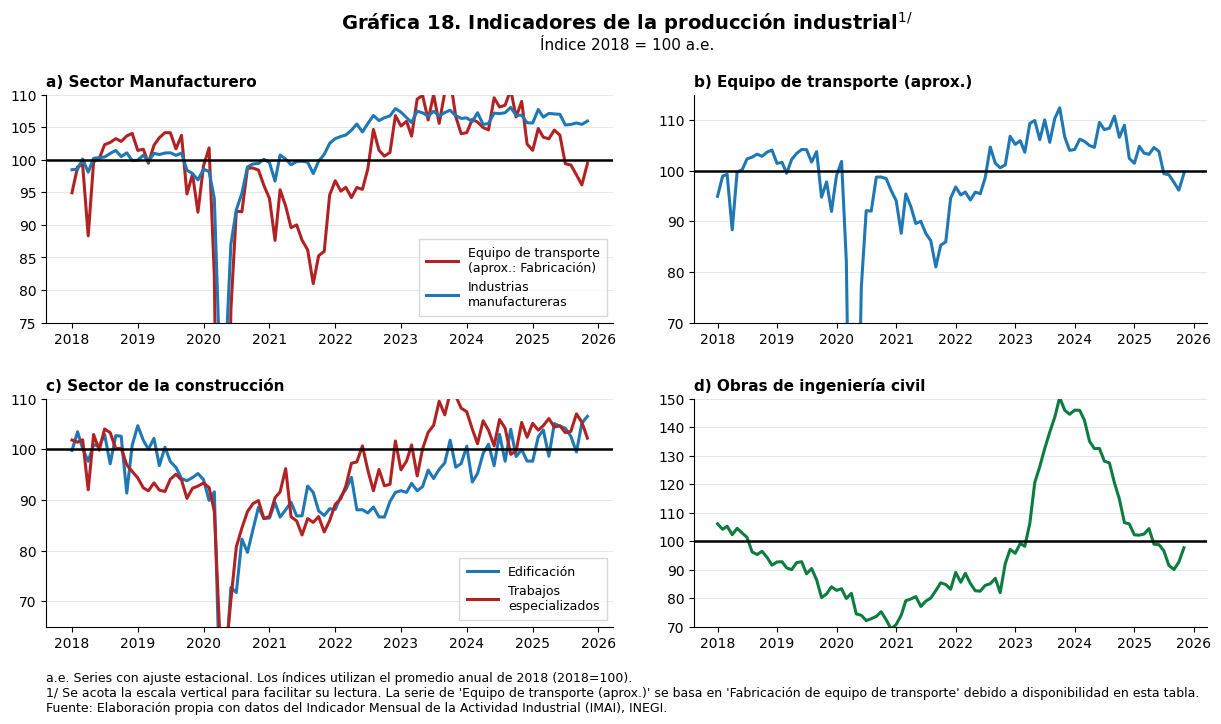

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
PATH_EXCEL = "raw/ivf_indice.xlsx"
SHEET_NAME = "IVF-indice"
START_DATE = "2018-01-01"
BASE_YEAR  = 2018

BLUE  = "#1f77b4"
RED   = "#b22222"
GREEN = "#0b7d3e"
BLACK = "#000000"

# =========================
# LECTOR MATRIZ (INEGI)
# =========================
MONTH_MAP = {
    "ENE": 1, "FEB": 2, "MAR": 3, "ABR": 4, "MAY": 5, "JUN": 6,
    "JUL": 7, "AGO": 8, "SEP": 9, "OCT": 10, "NOV": 11, "DIC": 12,
}

def read_ivf_matrix(path_excel: str, sheet_name: str) -> pd.DataFrame:
    raw = pd.read_excel(path_excel, sheet_name=sheet_name, header=None)

    month_row_candidates = raw.index[(raw.astype(str) == "ENE").any(axis=1)].tolist()
    if not month_row_candidates:
        raise ValueError("No encontré la fila de meses (ENE).")
    r_month = month_row_candidates[0]
    r_year  = r_month - 1
    r_data_start = r_month + 1

    c_start_candidates = raw.columns[raw.iloc[r_month].astype(str).eq("ENE")]
    if len(c_start_candidates) == 0:
        raise ValueError("No pude detectar la columna ENE.")
    c_start = int(c_start_candidates[0])

    years = pd.to_numeric(raw.iloc[r_year, c_start:], errors="coerce").ffill()
    months = raw.iloc[r_month, c_start:].astype(str).str.strip().str.upper().map(MONTH_MAP)
    dates = pd.to_datetime({"year": years.astype(int), "month": months.astype(int), "day": 1}, errors="coerce")

    series_col = 1
    data = raw.iloc[r_data_start:, [series_col] + list(range(c_start, raw.shape[1]))].copy()
    data.columns = ["serie"] + list(dates)

    data["serie"] = data["serie"].astype(str).str.strip()
    data = data[data["serie"].notna() & (data["serie"] != "") & (data["serie"].str.lower() != "nan")]

    long = data.melt(id_vars="serie", var_name="date", value_name="value")
    long["date"]  = pd.to_datetime(long["date"], errors="coerce")
    long["value"] = pd.to_numeric(long["value"], errors="coerce")
    long = long.dropna(subset=["date", "value"]).sort_values(["serie", "date"]).reset_index(drop=True)
    return long

df_long = read_ivf_matrix(PATH_EXCEL, SHEET_NAME)

# =========================
# SERIES (en tu archivo)
# =========================
S_MANUF_TOTAL = "Industrias manufactureras"
S_EQ_TRANS    = "Fabricación de equipo de transporte"  # <- APROX para "equipo de transporte"

S_EDIF        = "Edificación"
S_TRAB_ESP    = "Trabajos especializados para la construcción"
S_ING_CIVIL   = "Construcción de obras de ingeniería civil"

need = [S_MANUF_TOTAL, S_EQ_TRANS, S_EDIF, S_TRAB_ESP, S_ING_CIVIL]
missing = [s for s in need if s not in set(df_long["serie"].unique())]
if missing:
    raise ValueError("Faltan series en el Excel:\n- " + "\n- ".join(missing))

def get_series(name):
    d = df_long[df_long["serie"].eq(name)].copy().sort_values("date")
    d = d[d["date"] >= pd.to_datetime(START_DATE)]
    return d[["date", "value"]]

# =========================
# REBASE a prom. anual BASE_YEAR = 100 (a.e.)
# =========================
def rebase_year_avg(d: pd.DataFrame, col: str, base_year: int) -> pd.DataFrame:
    out = d.copy()
    out["year"] = out["date"].dt.year
    base = out.loc[out["year"].eq(base_year), col].mean()
    if pd.isna(base) or base == 0:
        raise ValueError(f"No pude calcular promedio anual {base_year} para {col}.")
    out[col + "_rb"] = out[col] / base * 100
    return out.drop(columns=["year"])

# Panel (a): dos índices comparables (NO restas)
A_manuf = get_series(S_MANUF_TOTAL).rename(columns={"value": "manuf_total"})
A_trans = get_series(S_EQ_TRANS).rename(columns={"value": "eq_trans_approx"})
A = A_manuf.merge(A_trans, on="date", how="inner").sort_values("date")

A = rebase_year_avg(A, "manuf_total", BASE_YEAR)
A = rebase_year_avg(A, "eq_trans_approx", BASE_YEAR)

# Panel (b): equipo de transporte (aprox.)
B = get_series(S_EQ_TRANS).rename(columns={"value": "eq_trans_approx"})
B = rebase_year_avg(B, "eq_trans_approx", BASE_YEAR)

# Panel (c): construcción
C_ed = get_series(S_EDIF).rename(columns={"value": "edif"})
C_te = get_series(S_TRAB_ESP).rename(columns={"value": "trab_esp"})
C = C_ed.merge(C_te, on="date", how="inner").sort_values("date")
C = rebase_year_avg(C, "edif", BASE_YEAR)
C = rebase_year_avg(C, "trab_esp", BASE_YEAR)

# Panel (d): ingeniería civil
D = get_series(S_ING_CIVIL).rename(columns={"value": "ing_civil"})
D = rebase_year_avg(D, "ing_civil", BASE_YEAR)

# =========================
# PLOT
# =========================
plt.close("all")
fig = plt.figure(figsize=(13.5, 7.6))

ax_a = fig.add_axes([0.07, 0.57, 0.42, 0.30])
ax_b = fig.add_axes([0.55, 0.57, 0.38, 0.30])
ax_c = fig.add_axes([0.07, 0.17, 0.42, 0.30])
ax_d = fig.add_axes([0.55, 0.17, 0.38, 0.30])

fig.text(0.5, 0.965, "Gráfica 18. Indicadores de la producción industrial$^{1/}$",
         ha="center", va="center", fontsize=14, fontweight="bold")
fig.text(0.5, 0.935, f"Índice {BASE_YEAR} = 100 a.e.",
         ha="center", va="center", fontsize=11)

def style_ax(ax):
    ax.axhline(100, color=BLACK, lw=1.8)
    ax.yaxis.grid(True, linewidth=0.6, alpha=0.35)
    ax.xaxis.grid(False)
    ax.tick_params(labelsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def set_ylim_quant(ax, series_list, step=5, qlo=0.02, qhi=0.98):
    y = pd.concat(series_list).dropna()
    lo = y.quantile(qlo)
    hi = y.quantile(qhi)
    lo = np.floor(lo/step)*step
    hi = np.ceil(hi/step)*step
    if lo == hi:
        lo -= step
        hi += step
    ax.set_ylim(lo, hi)

# --- Leyenda tipo tu ejemplo (recuadro, sin encimar)
def boxed_legend(ax, loc="lower right"):
    leg = ax.legend(
        loc=loc,
        frameon=True,
        fancybox=False,
        framealpha=.75,
        borderpad=0.6,
        handlelength=2.5,
        handletextpad=0.8,
        columnspacing=1.2,
        fontsize=9
    )
    return leg

# (a) Sector manufacturero
ax_a.plot(A["date"], A["eq_trans_approx_rb"], color=RED,  lw=2.2,
          label="Equipo de transporte\n(aprox.: Fabricación)")
ax_a.plot(A["date"], A["manuf_total_rb"], color=BLUE, lw=2.2,
          label="Industrias\nmanufactureras")
style_ax(ax_a)
ax_a.set_title("a) Sector Manufacturero", loc="left", fontsize=11, fontweight="bold", pad=6)
boxed_legend(ax_a, loc="lower right")
set_ylim_quant(ax_a, [A["eq_trans_approx_rb"], A["manuf_total_rb"]], step=5)

# (b) Equipo de transporte (aprox.)
ax_b.plot(B["date"], B["eq_trans_approx_rb"], color=BLUE, lw=2.2)
style_ax(ax_b)
ax_b.set_title("b) Equipo de transporte (aprox.)", loc="left", fontsize=11, fontweight="bold", pad=6)
set_ylim_quant(ax_b, [B["eq_trans_approx_rb"]], step=5)

# (c) Construcción
ax_c.plot(C["date"], C["edif_rb"], color=BLUE, lw=2.2, label="Edificación")
ax_c.plot(C["date"], C["trab_esp_rb"], color=RED,  lw=2.2, label="Trabajos\nespecializados")
style_ax(ax_c)
ax_c.set_title("c) Sector de la construcción", loc="left", fontsize=11, fontweight="bold", pad=6)
boxed_legend(ax_c, loc="lower right")
set_ylim_quant(ax_c, [C["edif_rb"], C["trab_esp_rb"]], step=5)

# (d) Ingeniería civil
ax_d.plot(D["date"], D["ing_civil_rb"], color=GREEN, lw=2.2)
style_ax(ax_d)
ax_d.set_title("d) Obras de ingeniería civil", loc="left", fontsize=11, fontweight="bold", pad=6)
set_ylim_quant(ax_d, [D["ing_civil_rb"]], step=10)

# Nota al pie (aclarando aproximación y SIN resta de índices)
nota = (
    f"a.e. Series con ajuste estacional. Los índices utilizan el promedio anual de {BASE_YEAR} ({BASE_YEAR}=100).\n"
    "1/ Se acota la escala vertical para facilitar su lectura. "
    "La serie de 'Equipo de transporte (aprox.)' se basa en 'Fabricación de equipo de transporte' "
    "debido a disponibilidad en esta tabla.\n"
    "Fuente: Elaboración propia con datos del Indicador Mensual de la Actividad Industrial (IMAI), INEGI."
)
fig.text(0.07, 0.055, nota, ha="left", va="bottom", fontsize=9)

plt.show()


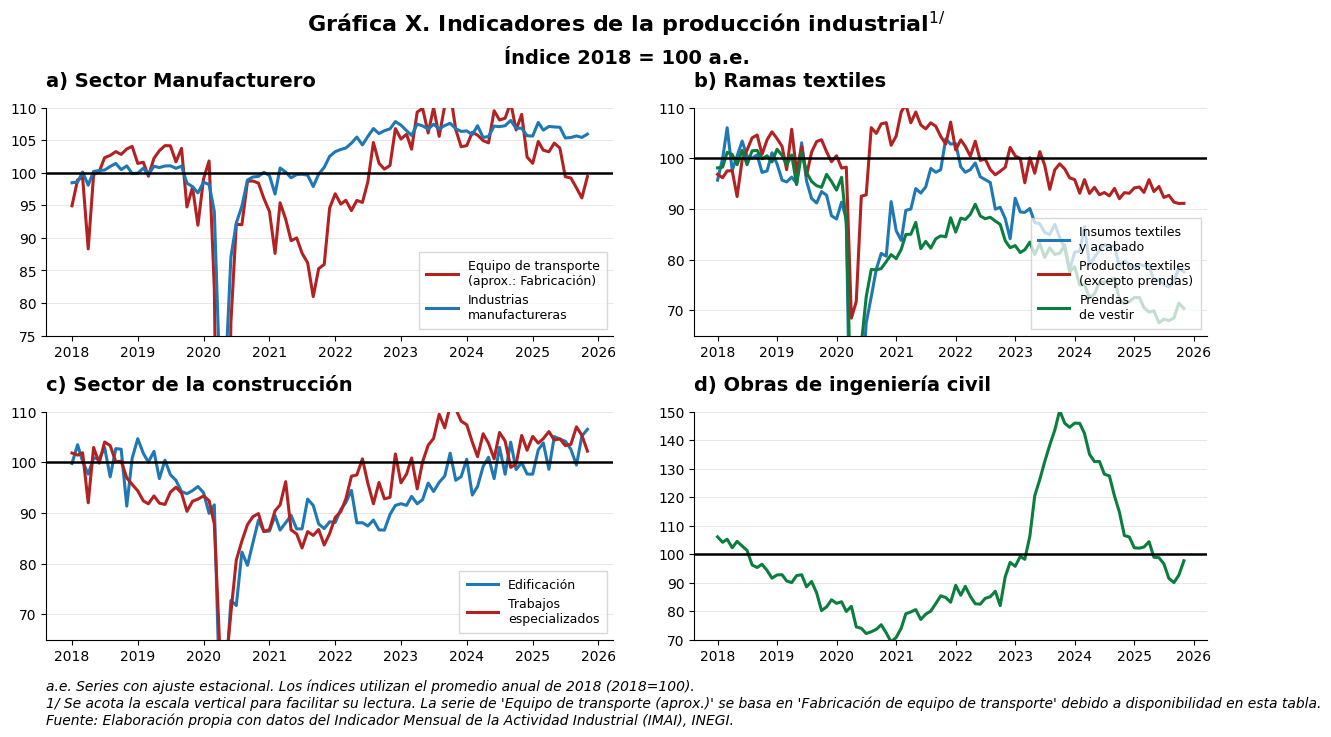

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
PATH_EXCEL = "raw/ivf_indice.xlsx"
SHEET_NAME = "IVF-indice"
START_DATE = "2018-01-01"
BASE_YEAR  = 2018

BLUE  = "#1f77b4"
RED   = "#b22222"
GREEN = "#0b7d3e"
BLACK = "#000000"

# =========================
# LECTOR MATRIZ (INEGI)
# =========================
MONTH_MAP = {
    "ENE": 1, "FEB": 2, "MAR": 3, "ABR": 4, "MAY": 5, "JUN": 6,
    "JUL": 7, "AGO": 8, "SEP": 9, "OCT": 10, "NOV": 11, "DIC": 12,
}

def read_ivf_matrix(path_excel: str, sheet_name: str) -> pd.DataFrame:
    raw = pd.read_excel(path_excel, sheet_name=sheet_name, header=None)

    month_row_candidates = raw.index[(raw.astype(str) == "ENE").any(axis=1)].tolist()
    if not month_row_candidates:
        raise ValueError("No encontré la fila de meses (ENE).")
    r_month = month_row_candidates[0]
    r_year  = r_month - 1
    r_data_start = r_month + 1

    c_start_candidates = raw.columns[raw.iloc[r_month].astype(str).eq("ENE")]
    if len(c_start_candidates) == 0:
        raise ValueError("No pude detectar la columna ENE.")
    c_start = int(c_start_candidates[0])

    years = pd.to_numeric(raw.iloc[r_year, c_start:], errors="coerce").ffill()
    months = raw.iloc[r_month, c_start:].astype(str).str.strip().str.upper().map(MONTH_MAP)
    dates = pd.to_datetime({"year": years.astype(int), "month": months.astype(int), "day": 1}, errors="coerce")

    series_col = 1
    data = raw.iloc[r_data_start:, [series_col] + list(range(c_start, raw.shape[1]))].copy()
    data.columns = ["serie"] + list(dates)

    data["serie"] = data["serie"].astype(str).str.strip()
    data = data[data["serie"].notna() & (data["serie"] != "") & (data["serie"].str.lower() != "nan")]

    long = data.melt(id_vars="serie", var_name="date", value_name="value")
    long["date"]  = pd.to_datetime(long["date"], errors="coerce")
    long["value"] = pd.to_numeric(long["value"], errors="coerce")
    long = long.dropna(subset=["date", "value"]).sort_values(["serie", "date"]).reset_index(drop=True)
    return long

df_long = read_ivf_matrix(PATH_EXCEL, SHEET_NAME)

# =========================
# SERIES (en tu archivo)
# =========================
S_MANUF_TOTAL = "Industrias manufactureras"
S_EQ_TRANS    = "Fabricación de equipo de transporte"  # (se deja para no cambiar el resto)

# --- NUEVAS series para Panel (b)
S_TEXT_INSUMOS = "Fabricación de insumos textiles y acabado de textiles"
S_TEXT_PROD    = "Fabricación de productos textiles, excepto prendas de vestir"
S_PRENDAS      = "Fabricación de prendas de vestir"

# --- Construcción (igual que antes)
S_EDIF        = "Edificación"
S_TRAB_ESP    = "Trabajos especializados para la construcción"
S_ING_CIVIL   = "Construcción de obras de ingeniería civil"

need = [
    S_MANUF_TOTAL,
    S_EQ_TRANS,          # se mantiene para no tocar panel (a) ni nota
    S_TEXT_INSUMOS,
    S_TEXT_PROD,
    S_PRENDAS,
    S_EDIF,
    S_TRAB_ESP,
    S_ING_CIVIL
]
missing = [s for s in need if s not in set(df_long["serie"].unique())]
if missing:
    raise ValueError("Faltan series en el Excel:\n- " + "\n- ".join(missing))

def get_series(name):
    d = df_long[df_long["serie"].eq(name)].copy().sort_values("date")
    d = d[d["date"] >= pd.to_datetime(START_DATE)]
    return d[["date", "value"]]

# =========================
# REBASE a prom. anual BASE_YEAR = 100 (a.e.)
# =========================
def rebase_year_avg(d: pd.DataFrame, col: str, base_year: int) -> pd.DataFrame:
    out = d.copy()
    out["year"] = out["date"].dt.year
    base = out.loc[out["year"].eq(base_year), col].mean()
    if pd.isna(base) or base == 0:
        raise ValueError(f"No pude calcular promedio anual {base_year} para {col}.")
    out[col + "_rb"] = out[col] / base * 100
    return out.drop(columns=["year"])

# Panel (a): dos índices comparables (NO restas)
A_manuf = get_series(S_MANUF_TOTAL).rename(columns={"value": "manuf_total"})
A_trans = get_series(S_EQ_TRANS).rename(columns={"value": "eq_trans_approx"})
A = A_manuf.merge(A_trans, on="date", how="inner").sort_values("date")

A = rebase_year_avg(A, "manuf_total", BASE_YEAR)
A = rebase_year_avg(A, "eq_trans_approx", BASE_YEAR)

# Panel (b): --- AHORA 3 ramas textiles
B_i = get_series(S_TEXT_INSUMOS).rename(columns={"value": "insumos"})
B_p = get_series(S_TEXT_PROD).rename(columns={"value": "prod"})
B_v = get_series(S_PRENDAS).rename(columns={"value": "vestir"})

B = (
    B_i.merge(B_p, on="date", how="inner")
       .merge(B_v, on="date", how="inner")
       .sort_values("date")
)

B = rebase_year_avg(B, "insumos", BASE_YEAR)
B = rebase_year_avg(B, "prod", BASE_YEAR)
B = rebase_year_avg(B, "vestir", BASE_YEAR)

# Panel (c): construcción
C_ed = get_series(S_EDIF).rename(columns={"value": "edif"})
C_te = get_series(S_TRAB_ESP).rename(columns={"value": "trab_esp"})
C = C_ed.merge(C_te, on="date", how="inner").sort_values("date")
C = rebase_year_avg(C, "edif", BASE_YEAR)
C = rebase_year_avg(C, "trab_esp", BASE_YEAR)

# Panel (d): ingeniería civil
D = get_series(S_ING_CIVIL).rename(columns={"value": "ing_civil"})
D = rebase_year_avg(D, "ing_civil", BASE_YEAR)

# =========================
# PLOT
# =========================
plt.close("all")
fig = plt.figure(figsize=(13.5, 7.6))

ax_a = fig.add_axes([0.07, 0.57, 0.42, 0.30])
ax_b = fig.add_axes([0.55, 0.57, 0.38, 0.30])
ax_c = fig.add_axes([0.07, 0.17, 0.42, 0.30])
ax_d = fig.add_axes([0.55, 0.17, 0.38, 0.30])

fig.suptitle( "Gráfica X. Indicadores de la producción industrial$^{1/}$",
         ha="center", va="center", fontsize=16, fontweight="bold")
fig.text(0.5, 0.935, f"Índice {BASE_YEAR} = 100 a.e.",
         ha="center", va="center", fontsize=14, fontweight="bold")

def style_ax(ax):
    ax.axhline(100, color=BLACK, lw=1.8)
    ax.yaxis.grid(True, linewidth=0.6, alpha=0.35)
    ax.xaxis.grid(False)
    ax.tick_params(labelsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def set_ylim_quant(ax, series_list, step=5, qlo=0.02, qhi=0.98):
    y = pd.concat(series_list).dropna()
    lo = y.quantile(qlo)
    hi = y.quantile(qhi)
    lo = np.floor(lo/step)*step
    hi = np.ceil(hi/step)*step
    if lo == hi:
        lo -= step
        hi += step
    ax.set_ylim(lo, hi)

# --- Leyenda tipo tu ejemplo (recuadro, sin encimar)
def boxed_legend(ax, loc="lower right"):
    leg = ax.legend(
        loc=loc,
        frameon=True,
        fancybox=False,
        framealpha=.75,
        borderpad=0.6,
        handlelength=2.5,
        handletextpad=0.8,
        columnspacing=1.2,
        fontsize=9
    )
    return leg

# (a) Sector manufacturero
ax_a.plot(A["date"], A["eq_trans_approx_rb"], color=RED,  lw=2.2,
          label="Equipo de transporte\n(aprox.: Fabricación)")
ax_a.plot(A["date"], A["manuf_total_rb"], color=BLUE, lw=2.2,
          label="Industrias\nmanufactureras")
style_ax(ax_a)
ax_a.set_title("a) Sector Manufacturero", loc="left",fontsize=14, fontweight="bold", pad=15)
boxed_legend(ax_a, loc="lower right")
set_ylim_quant(ax_a, [A["eq_trans_approx_rb"], A["manuf_total_rb"]], step=5)

# (b) Ramas textiles (3 líneas)
ax_b.plot(B["date"], B["insumos_rb"], color=BLUE,  lw=2.2, label="Insumos textiles\ny acabado")
ax_b.plot(B["date"], B["prod_rb"],    color=RED,   lw=2.2, label="Productos textiles\n(excepto prendas)")
ax_b.plot(B["date"], B["vestir_rb"],  color=GREEN, lw=2.2, label="Prendas\nde vestir")
style_ax(ax_b)
ax_b.set_title("b) Ramas textiles", loc="left", fontsize=14, fontweight="bold", pad=15)
boxed_legend(ax_b, loc="lower right")
set_ylim_quant(ax_b, [B["insumos_rb"], B["prod_rb"], B["vestir_rb"]], step=5)

# (c) Construcción
ax_c.plot(C["date"], C["edif_rb"], color=BLUE, lw=2.2, label="Edificación")
ax_c.plot(C["date"], C["trab_esp_rb"], color=RED,  lw=2.2, label="Trabajos\nespecializados")
style_ax(ax_c)
ax_c.set_title("c) Sector de la construcción", loc="left", fontsize=14, fontweight="bold", pad=15)
boxed_legend(ax_c, loc="lower right")
set_ylim_quant(ax_c, [C["edif_rb"], C["trab_esp_rb"]], step=5)

# (d) Ingeniería civil
ax_d.plot(D["date"], D["ing_civil_rb"], color=GREEN, lw=2.2)
style_ax(ax_d)
ax_d.set_title("d) Obras de ingeniería civil", loc="left", fontsize=14, fontweight="bold", pad=15)
set_ylim_quant(ax_d, [D["ing_civil_rb"]], step=10)

# Nota al pie (se deja igual que tu versión original)
nota = (
    f"a.e. Series con ajuste estacional. Los índices utilizan el promedio anual de {BASE_YEAR} ({BASE_YEAR}=100).\n"
    "1/ Se acota la escala vertical para facilitar su lectura. "
    "La serie de 'Equipo de transporte (aprox.)' se basa en 'Fabricación de equipo de transporte' "
    "debido a disponibilidad en esta tabla.\n"
    "Fuente: Elaboración propia con datos del Indicador Mensual de la Actividad Industrial (IMAI), INEGI."
)
fig.text(0.07, 0.055, nota, ha="left", va="bottom", fontsize=10, style="italic")

plt.show()
